# K-Drama Rating Prediction
**วิชา 1145 201 คณิตศาสตร์สำหรับวิทยาการข้อมูล | Final Project**
ผู้จัดทำ: `[ชื่อ-รหัสนักศึกษา]`

**Dataset:** Top Korean Drama List (~1500) — สแครปจาก MyDramaList (Kaggle: noorrizki), 1,647 แถว

**คำถามวิจัย:** ปัจจัยอะไรของซีรีส์เกาหลี (network, แนว, จำนวนตอน, ปีที่ฉาย ฯลฯ) ที่ทำนายคะแนนรีวิว (`Score`) ได้ดีที่สุด?

| CLO | ส่วนใน Notebook |
|---|---|
| CLO1 Linear Algebra | ข้อ 4: PCA/SVD |
| CLO2 EDA + Stats | ข้อ 2-3, 6 (Bias-Variance), 8 (Bootstrap) |
| CLO3 Model | ข้อ 5 |
| CLO4 Cross-Validation | ข้อ 7 |

## 0. Setup

In [83]:
# นำเข้าไลบรารีที่ใช้ทั้งหมด
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

RANDOM_STATE = 42          # fix seed เพื่อให้ผลรันซ้ำได้
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')


## 1. Data Loading
Dataset จริง: `dataset.csv` (1,647 rows x 12 cols)
คอลัมน์ดิบ: `Unnamed: 0, Name, Year, Genre, Main Cast, Sinopsis, Score, Content Rating, Tags, Network, img url, Episode`

In [84]:
DATA_PATH = 'dataset.csv'
TARGET    = 'Score'

import os
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    DEMO = False
else:
    # ข้อมูลจำลองไว้ทดสอบ pipeline เท่านั้น (ห้ามส่งงานจริงด้วยข้อมูลนี้)
    DEMO = True
    rng = np.random.default_rng(RANDOM_STATE)
    n = 800
    nets = rng.choice(['tvN','JTBC','KBS2','SBS','MBC','Netflix'], n, p=[.2,.15,.15,.15,.15,.2])
    allg = ['Romance','Comedy','Thriller','Historical','Fantasy','Medical','Melodrama']
    genres = [', '.join(rng.choice(allg, rng.integers(1,4), replace=False)) for _ in range(n)]
    tags = [', '.join(rng.choice(['Revenge','Time Travel','Workplace','Bromance','Suspense'], rng.integers(1,4), replace=False)) for _ in range(n)]
    cast = [', '.join([f'Actor{i}' for i in rng.integers(0,999,rng.integers(2,6))]) for _ in range(n)]
    synopsis = ['word '*rng.integers(20,120).item() for _ in range(n)]
    year = rng.integers(2005, 2025, n); eps = rng.choice([12,16,20,32], n)
    content_rating = rng.choice(['13+','15+','18+'], n)
    score = (6.5 + .002*(year-2005) - .0002*eps + .4*(nets=='Netflix')
             + .3*np.array(['Thriller' in g for g in genres]) + rng.normal(0,.35,n))
    df = pd.DataFrame({'Unnamed: 0': range(n), 'Name': [f'Drama {i}' for i in range(n)],
        'Year': year, 'Genre': genres, 'Main Cast': cast, 'Sinopsis': synopsis,
        'Score': score.clip(5,9.8), 'Content Rating': content_rating, 'Tags': tags,
        'Network': nets, 'img url': '', 'Episode': eps})
print('DEMO MODE' if DEMO else 'Loaded real data', df.shape)
df.head()

Loaded real data (1647, 12)


,Unnamed: 0,Name,Year,Genre,Main Cast,Sinopsis,Score,Content Rating,Tags,Network,img url,Episode
0,0,Move to Heaven,2021,"Life, Drama","Lee Je Hoon, Tang Jun Sang, Hong Seung Hee, Ju...",Han Geu Roo is an autistic 20-year-old. He wor...,9.2,18+ Restricted (violence & profanity),"Uncle-Nephew Relationship,, Autism,, Death,, S...",Netflix,https://i.mydramalist.com/Rle36_4c.jpg?v=1,10 episodes
1,1,Weak Hero Class 1,2022,"Action, Youth, Drama","Park Ji Hoon, Choi Hyun Wook, Hong Kyung, Kim ...",Yeon Shi Eun is a model student who ranks at t...,9.1,18+ Restricted (violence & profanity),"Smart Male Lead,, Bromance,, School Bullying,,...","Wavve, iQIYI, Viki",https://i.mydramalist.com/pq2lr_4c.jpg?v=1,8 episodes
2,2,Hospital Playlist Season 2,2021,"Romance, Life, Drama, Medical","Jo Jung Suk, Yoo Yeon Seok, Jung Kyung Ho, Kim...",Everyday is extraordinary for five doctors and...,9.1,15+ - Teens 15 or older,"Multiple Mains,, Band,, Music,, Strong Female ...","TVING, Netflix",https://i.mydramalist.com/dKY0d_4c.jpg?v=1,12 episodes
3,3,Flower of Evil,2020,"Thriller, Romance, Crime, Melodrama","Lee Joon Gi, Moon Chae Won, Jang Hee Jin, Seo ...",Although Baek Hee Sung is hiding a dark secret...,9.1,15+ - Teens 15 or older,"Deception,, Family Secret,, Mystery,, Suspense...","Prime Video, Apple TV, Viki, Netflix",https://i.mydramalist.com/WAEAp_4c.jpg?v=1,16 episodes
4,4,Hospital Playlist,2020,"Romance, Life, Drama, Medical","Jo Jung Suk, Yoo Yeon Seok, Jung Kyung Ho, Kim...","""The stories of people going through their day...",9.1,15+ - Teens 15 or older,"Nice Male Lead,, Multiple Mains,, Slow Romance...",Netflix,https://i.mydramalist.com/RXXL6_4c.jpg?v=1,12 episodes


In [85]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Data Cleaning, Feature Engineering และ EDA (CLO2)

In [86]:
# ดูภาพรวมและ missing values
print(df.dtypes); print(); print(df.isna().sum())

Unnamed: 0          int64
Name               object
Year                int64
Genre              object
Main Cast          object
Sinopsis           object
Score             float64
Content Rating     object
Tags               object
Network            object
img url            object
Episode            object
dtype: object

Unnamed: 0         0
Name               0
Year               0
Genre              0
Main Cast          0
Sinopsis           5
Score              0
Content Rating     0
Tags              19
Network            0
img url            0
Episode            0
dtype: int64


In [87]:
# แปลง Score เป็นตัวเลข (บางแถวอาจมีค่าว่างหรือ string), ตัดแถวที่ไม่มี target
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
df = df.dropna(subset=['Score']).copy()

# สร้าง numeric features จากคอลัมน์ข้อความ (สำคัญ: ต้องมี >=5 numeric features)
df['Main Cast'] = df['Main Cast'].fillna('')
df['Genre']     = df['Genre'].fillna('')
df['Tags']      = df['Tags'].fillna('')
df['Sinopsis']  = df['Sinopsis'].fillna('')

df['n_cast']       = df['Main Cast'].apply(lambda s: len([x for x in s.split(',') if x.strip()]))
df['n_genres']     = df['Genre'].apply(lambda s: len([x for x in s.split(',') if x.strip()]))
df['n_tags']       = df['Tags'].apply(lambda s: len([x for x in s.split(',') if x.strip()]))
df['synopsis_len'] = df['Sinopsis'].str.split().str.len().fillna(0)

df['Year']    = pd.to_numeric(df['Year'], errors='coerce')
df['Episode'] = df['Episode'].astype(str).str.extract(r'(\d+)').astype(float)

NUM_COLS = ['Year', 'Episode', 'n_cast', 'n_genres', 'n_tags', 'synopsis_len']  # 6 numeric features

# ตรวจสอบ missing ก่อนเติมค่า (ถ้า NaN เยอะผิดปกติ ให้ไปดูคอลัมน์ต้นทาง เช่น Year/Episode มีรูปแบบไม่ใช่ตัวเลขล้วน)
print('NaN ต่อคอลัมน์ก่อนเติมค่า:'); print(df[NUM_COLS].isna().sum())

for c in NUM_COLS:
    med = df[c].median()
    if pd.isna(med):          # กรณีทั้งคอลัมน์แปลงเป็นตัวเลขไม่ได้เลยสักแถว ใช้ 0 แทน
        med = 0
    df[c] = df[c].fillna(med)

assert not df[NUM_COLS].isna().any().any(), 'ยังมี NaN หลงเหลือใน NUM_COLS'

CAT_COL   = 'Network'
RATE_COL  = 'Content Rating'
GENRE_COL = 'Genre'
df[CAT_COL]  = df[CAT_COL].fillna('Other')
df[RATE_COL] = df[RATE_COL].fillna('Unknown')

df[NUM_COLS + ['Score']].describe().T

NaN ต่อคอลัมน์ก่อนเติมค่า:
Year            0
Episode         0
n_cast          0
n_genres        0
n_tags          0
synopsis_len    0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Year,1647.0,2015.969035,4.990600,1995.0,2013.0,2017.0,2020.0,2023.0
Episode,1647.0,22.524590,24.550055,1.0,12.0,16.0,20.0,210.0
n_cast,1647.0,5.891925,0.501978,1.0,6.0,6.0,6.0,6.0
n_genres,1647.0,3.338191,0.800451,1.0,3.0,4.0,4.0,7.0
n_tags,1647.0,8.973892,2.434298,0.0,9.0,10.0,10.0,13.0
synopsis_len,1647.0,153.105039,110.373889,0.0,63.5,127.0,219.5,669.0
Score,1647.0,7.691743,0.528327,6.5,7.3,7.6,8.1,9.2


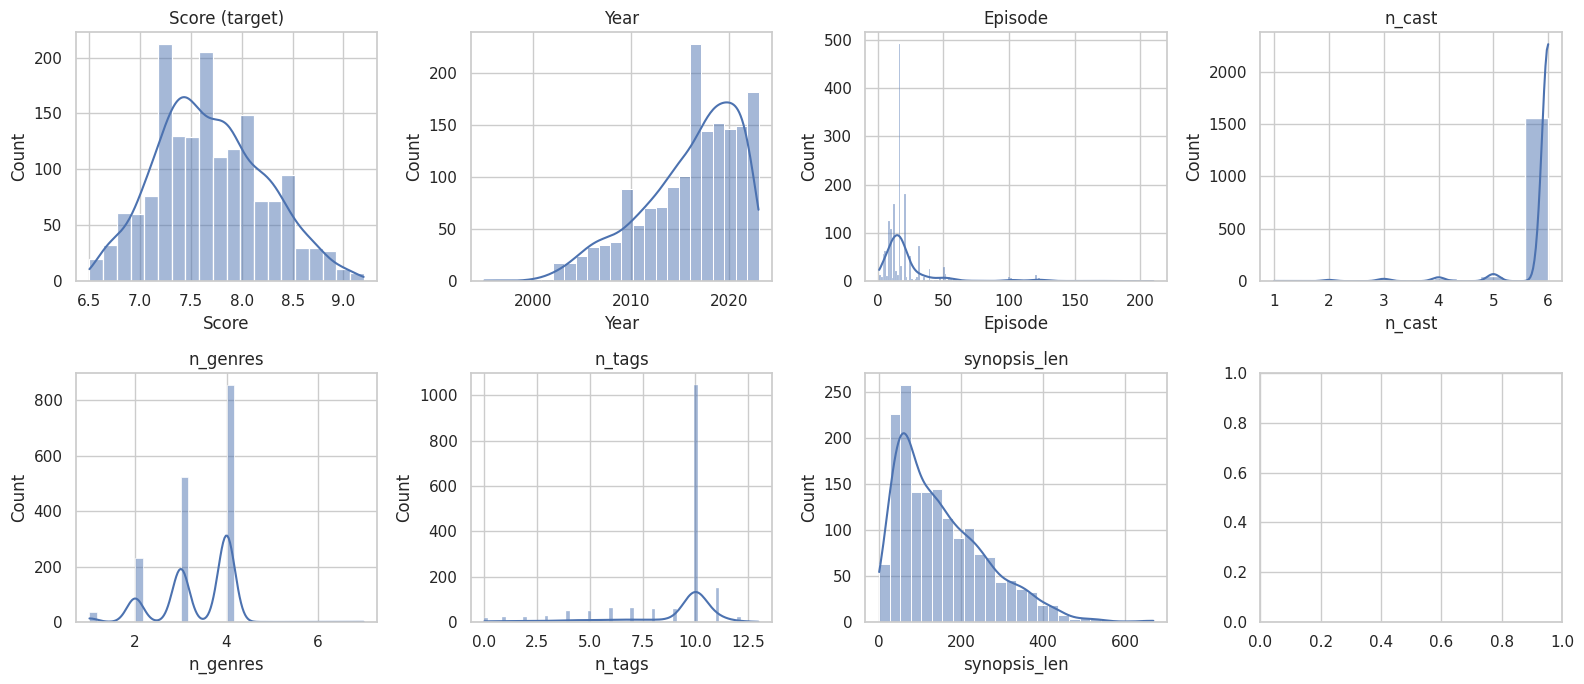

In [88]:
# กราฟ distribution ของ target และตัวแปรตัวเลข
fig, ax = plt.subplots(2, 4, figsize=(16, 7)); ax = ax.ravel()
sns.histplot(df['Score'], kde=True, ax=ax[0]); ax[0].set_title('Score (target)')
for a, c in zip(ax[1:], NUM_COLS):
    sns.histplot(df[c], kde=True, ax=a); a.set_title(c)
plt.tight_layout(); plt.show()

**Insight ข้อ 2 — Distribution

Score กระจายตัวแบบเบ้ซ้ายเล็กน้อย (left-skewed) ส่วนใหญ่กระจุกตัวอยู่ช่วง 7.3–8.1 (IQR) มีค่าเฉลี่ย 7.69 และ std เพียง 0.53 ซึ่งแคบมากเมื่อเทียบกับช่วงคะแนนที่เป็นไปได้ (6.5–9.2) สะท้อนว่าซีรีส์ในชุดข้อมูลนี้ส่วนใหญ่ "ได้รับความนิยมพอสมควรอยู่แล้ว" ซึ่งน่าจะเป็น selection bias จาก MyDramaList เพราะผู้ใช้มักให้คะแนนเฉพาะเรื่องที่ตนเองดูจบและชอบในระดับหนึ่ง ซีรีส์ที่ดูไม่จบหรือไม่มีใครรีวิวจึงไม่ปรากฏในชุดข้อมูล

ตัวแปร n_tags และ n_genres มีลักษณะเป็น discrete/กระจุกตัวที่ค่าบางค่า (เช่น 9-10 tags, 3-4 genres) ไม่ได้กระจายแบบต่อเนื่อง ส่วน synopsis_len มีลักษณะเบ้ขวาชัดเจน (ส่วนใหญ่สั้น มีบางเรื่องที่เรื่องย่อยาวผิดปกติ) จึงเป็นเหตุผลที่ทำ log-transform ก่อนเข้าโมเดล

In [89]:
# Log-transform ตัวแปรที่มักเบ้ขวา (จำนวนนักแสดง, ความยาว synopsis)
for c in ['n_cast', 'synopsis_len']:
    df[c] = np.log1p(df[c])

# Multi-hot สำหรับ genre และ dummy สำหรับ network / content rating
genre_dummies = df[GENRE_COL].str.get_dummies(sep=',')
genre_dummies.columns = [c.strip() for c in genre_dummies.columns]
genre_dummies = genre_dummies.T.groupby(level=0).max().T   # รวมคอลัมน์ที่ชื่อซ้ำกัน (เว้นวรรคต่างกัน)
genre_dummies = genre_dummies.loc[:, genre_dummies.sum() >= 20]   # ตัดแนวที่น้อยเกินไป

net_dummies  = pd.get_dummies(df[CAT_COL], prefix='net', drop_first=True)
rate_dummies = pd.get_dummies(df[RATE_COL], prefix='rate', drop_first=True)
print('genre features kept:', list(genre_dummies.columns))

genre features kept: ['Action', 'Business', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Food', 'Historical', 'Horror', 'Law', 'Life', 'Medical', 'Melodrama', 'Music', 'Mystery', 'Political', 'Psychological', 'Romance', 'Sci-Fi', 'Sitcom', 'Sports', 'Supernatural', 'Thriller', 'Youth']


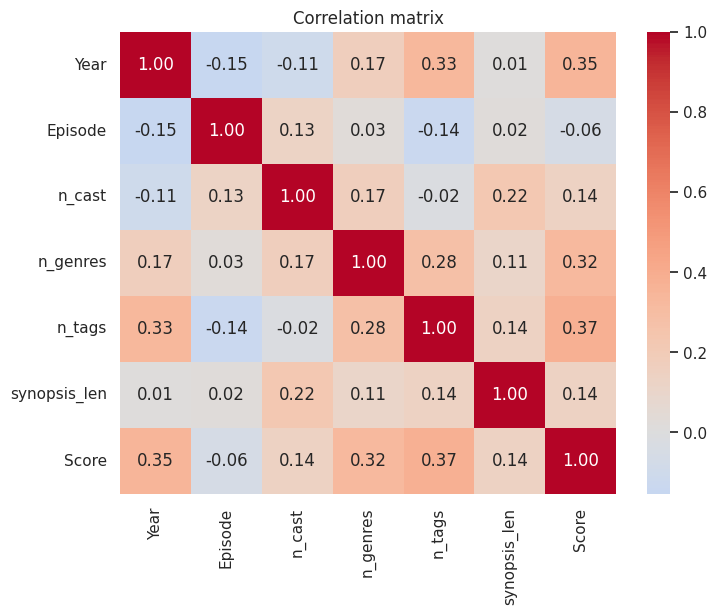

In [90]:
# Correlation heatmap ของตัวแปรตัวเลข
plt.figure(figsize=(8, 6))
sns.heatmap(df[NUM_COLS + ['Score']].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix'); plt.show()

**Insight Correlation

จาก correlation matrix พบว่า n_tags มีความสัมพันธ์กับ Score สูงสุด (0.37) รองลงมาคือ n_genres (0.32) และ Year (0.35) ซึ่งทั้งหมดเป็นค่าระดับปานกลาง-ต่ำ บ่งชี้ว่าไม่มีตัวแปรตัวเดียวที่อธิบาย Score ได้ชัดเจนมาก ต้องอาศัยหลายตัวแปรร่วมกัน (ซึ่งสอดคล้องกับ R² ที่ได้จากโมเดลในข้อ 5 ที่อยู่ราว 0.4)

ส่วน n_cast และ synopsis_len สัมพันธ์กับ Score ค่อนข้างต่ำ (~0.14) ไม่พบคู่ตัวแปรใดที่ correlation สูงเกิน 0.4 จึงไม่มีปัญหา multicollinearity รุนแรงในกลุ่มตัวแปรตัวเลขนี้ (ปัญหา multicollinearity ที่เจอใน Linear Regression ข้อ 5 น่าจะมาจาก dummy variables ของ genre/network ที่ไม่ได้แสดงใน heatmap นี้ ไม่ใช่จาก 6 ตัวแปรหลัก)

## 3. Statistical Tests (CLO2)

ANOVA by Network: F=10.26, p=5.94e-33


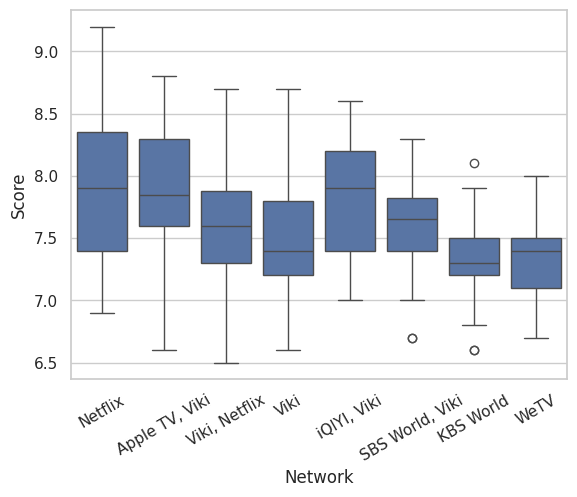

Welch t-test [Romance] vs others: t=-9.82, p=1.959e-21, mean diff=-0.291


In [91]:
# ANOVA: Score ต่างกันตาม network หรือไม่?
groups = [g['Score'].values for _, g in df.groupby(CAT_COL) if len(g) >= 10]
F, p = stats.f_oneway(*groups)
print(f'ANOVA by {CAT_COL}: F={F:.2f}, p={p:.4g}')
top_nets = df[CAT_COL].value_counts().head(8).index
sns.boxplot(data=df[df[CAT_COL].isin(top_nets)], x=CAT_COL, y='Score')
plt.xticks(rotation=30); plt.show()

# t-test: แนวที่พบมากสุด เทียบกับแนวอื่น
g0 = genre_dummies.sum().idxmax()
a, b = df.loc[genre_dummies[g0] == 1, 'Score'], df.loc[genre_dummies[g0] == 0, 'Score']
t, p = stats.ttest_ind(a, b, equal_var=False)
print(f'Welch t-test [{g0}] vs others: t={t:.2f}, p={p:.4g}, mean diff={a.mean()-b.mean():.3f}')

**Insight ANOVA/t-test

ผล ANOVA ระหว่าง Network ให้ F=10.26, p=5.94×10⁻³³ ซึ่งน้อยกว่า α=0.05 อย่างมาก จึงปฏิเสธ H0 และสรุปได้ว่าคะแนนเฉลี่ยแตกต่างกันอย่างมีนัยสำคัญทางสถิติระหว่าง network จาก boxplot เห็นชัดว่า Netflix มี median คะแนนสูงสุด ขณะที่ KBS World และ WeTV มี median ต่ำสุด ซึ่งอาจสะท้อนว่าแพลตฟอร์ม streaming ระดับโลกคัดสรรคอนเทนต์คุณภาพสูงกว่า หรือมีกลุ่มผู้ชมที่ rate ใจดีกว่า

ผล t-test เปรียบเทียบแนว Romance กับแนวอื่น ให้ t=-9.82, p=1.96×10⁻²¹ ซึ่งปฏิเสธ H0 เช่นกัน โดย mean diff=-0.291 หมายความว่าซีรีส์แนว Romance ได้คะแนนเฉลี่ยต่ำกว่าแนวอื่นประมาณ 0.29 แต้ม แม้ค่า p จะน้อยมาก (นัยสำคัญทางสถิติสูง) แต่ขนาดผลต่าง 0.29 แต้มบนสเกล 6.5-9.2 ถือว่ามีนัยสำคัญเชิงปฏิบัติในระดับปานกลาง ไม่ใช่ผลที่ใหญ่มาก อาจเพราะแนว Romance เป็นแนวที่มีซีรีส์จำนวนมากที่สุด (เจือจางด้วยทั้งเรื่องดังและเรื่องธรรมดา) ต่างจากแนว niche ที่มีน้อยเรื่องแต่คัดสรรมาดี

## 4. PCA / SVD (CLO1)

In [92]:
# Standardize ก่อน PCA เสมอ (PCA ไวต่อ scale)
X_num = df[NUM_COLS].values
X_scaled = StandardScaler().fit_transform(X_num)

# --- SVD ด้วยมือ: X = U S V^T ---
U, S, Vt = np.linalg.svd(X_scaled, full_matrices=False)
explained = S**2 / np.sum(S**2)
print('Explained variance ratio (SVD):', np.round(explained, 3))

# ยืนยันว่า sklearn PCA ให้ผลตรงกัน
pca = PCA().fit(X_scaled)
print('sklearn PCA:', np.round(pca.explained_variance_ratio_, 3))
assert np.allclose(explained, pca.explained_variance_ratio_)

Explained variance ratio (SVD): [0.268 0.228 0.155 0.133 0.114 0.102]
sklearn PCA: [0.268 0.228 0.155 0.133 0.114 0.102]


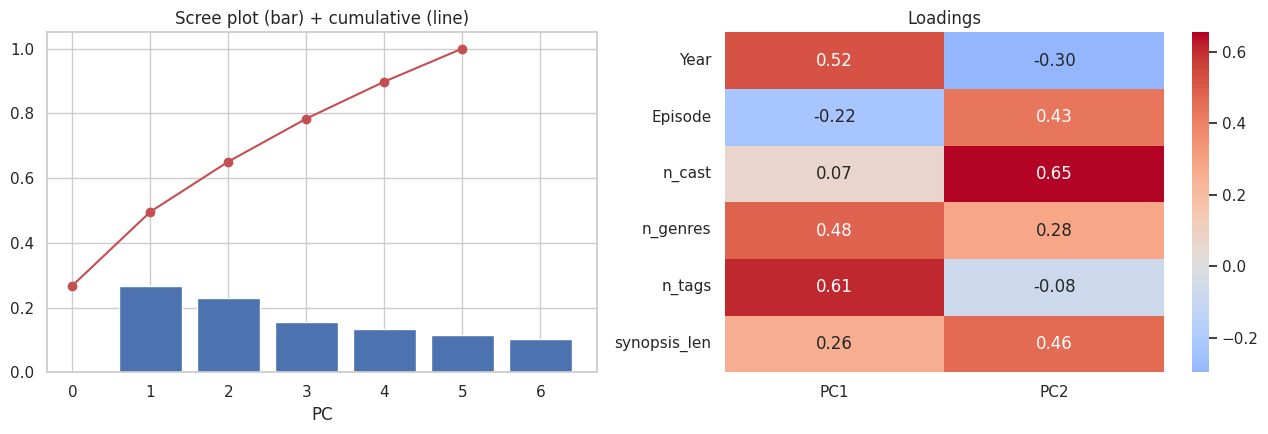

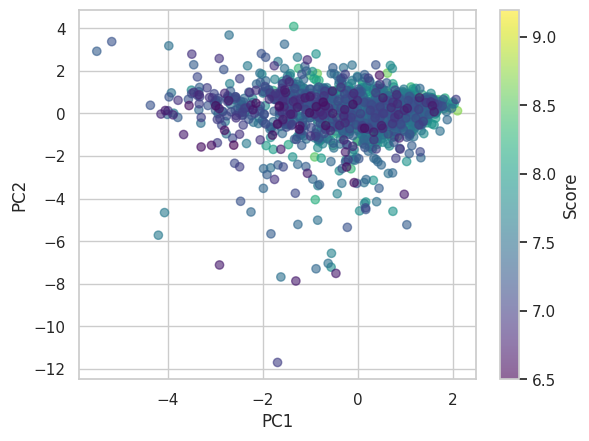

In [93]:
# Scree plot + loadings
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(range(1, len(explained)+1), explained); ax[0].plot(np.cumsum(explained), 'r-o')
ax[0].set_title('Scree plot (bar) + cumulative (line)'); ax[0].set_xlabel('PC')
loadings = pd.DataFrame(pca.components_[:2].T, index=NUM_COLS, columns=['PC1', 'PC2'])
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[1]); ax[1].set_title('Loadings')
plt.tight_layout(); plt.show()

# Scatter บน PC1-PC2 สีตาม Score
Z = pca.transform(X_scaled)
plt.scatter(Z[:,0], Z[:,1], c=df['Score'], cmap='viridis', alpha=.6); plt.colorbar(label='Score')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()

PC1 อธิบายความแปรปรวนได้ 26.8% ตัวแปรที่มี loading สูงสุดคือ n_tags (0.61) และ Year (0.52) รองลงมาคือ n_genres (0.48) ทั้งหมดเป็นบวกและไปทิศทางเดียวกัน จึงตีความ PC1 ได้ว่าสะท้อน "ความละเอียดของ metadata ในซีรีส์ยุคหลัง" — ซีรีส์ที่ออกฉายปีหลังๆ มักถูกติด tag และใส่แนวเรื่อง (genre) ไว้ละเอียดกว่าซีรีส์เก่า ส่วน Episode มี loading ติดลบเล็กน้อย (-0.22) แปลว่าซีรีส์ยุคหลังมักมีตอนน้อยกว่า (สวนทางกับละครยุคเก่าที่มักยาวเป็นร้อยตอน)

PC2 อธิบาย 22.8% มี loading สูงสุดจาก n_cast (0.65) และ synopsis_len (0.46) รองลงมาคือ Episode (0.43) จึงตีความได้ว่าสะท้อน "ขนาดโปรดักชัน" — ซีรีส์ที่มีนักแสดงเยอะ เรื่องย่อยาว และจำนวนตอนเยอะ มักเป็นโปรดักชันใหญ่หรือละครแนว daily drama ที่ฉายยาว

ต้องใช้ 5 PC ถึงจะครอบคลุม ≥80% ของความแปรปรวน (PC1-PC5 รวมกันได้ 89.8%) แสดงว่าทั้ง 6 ตัวแปรมีความเป็นอิสระต่อกันพอสมควร ไม่มีตัวไหนซ้ำซ้อนกันมากจนยุบรวมเป็น PC เดียวได้

จาก scatter plot PC1 vs PC2 สีตาม Score ไม่เห็น pattern ชัดเจนว่าคะแนนสูง/ต่ำแยกเป็นกลุ่มตามตำแหน่งบน PC1-PC2 (จุดสีเหลือง-เขียว-ม่วงกระจายปะปนกัน) บ่งชี้ว่าตัวแปร metadata เพียงอย่างเดียวไม่สามารถอธิบาย Score ได้ดีนัก อาจต้องพึ่งตัวแปรอื่น เช่น network หรือ genre เฉพาะเจาะจง (ซึ่งสอดคล้องกับผล ANOVA/t-test ในข้อ 3 ที่พบว่า network และ genre มีผลต่อ Score อย่างมีนัยสำคัญ)

## 5. Modeling (CLO3)

In [94]:
# สร้าง feature matrix รวม + แบ่ง train/test ก่อนเทรนทุกอย่าง
X = pd.concat([df[NUM_COLS], net_dummies, rate_dummies, genre_dummies], axis=1).astype(float)
y = df['Score']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

models = {
    'Linear':        make_pipeline(StandardScaler(), LinearRegression()),
    'Ridge':         make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'KNN':           make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=7)),  # ต้อง standardize
    'RandomForest':  RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'GradBoost':     GradientBoostingRegressor(random_state=RANDOM_STATE),
}
rows = []
for name, m in models.items():
    m.fit(X_tr, y_tr)
    pr_tr, pr_te = m.predict(X_tr), m.predict(X_te)
    rows.append(dict(model=name,
        train_RMSE=mean_squared_error(y_tr, pr_tr)**.5, test_RMSE=mean_squared_error(y_te, pr_te)**.5,
        test_MAE=mean_absolute_error(y_te, pr_te), test_R2=r2_score(y_te, pr_te)))
results = pd.DataFrame(rows).set_index('model').round(3)
results

,train_RMSE,test_RMSE,test_MAE,test_R2
model,,,,
Linear,0.331,0.597,0.454,-0.348
Ridge,0.332,0.488,0.389,0.099
KNN,0.397,0.445,0.357,0.251
RandomForest,0.150,0.388,0.310,0.431
GradBoost,0.345,0.394,0.318,0.413


**InterpretationRandom Forest

ให้ผลดีที่สุดบน Test set ด้วย Test RMSE ต่ำสุด (0.388) และ R² สูงสุด (0.431) ตามมาติดๆ ด้วย GradBoost (RMSE=0.394, R²=0.413) ซึ่งใกล้เคียงกันมากจนถือว่าทั้งสองโมเดลให้ประสิทธิภาพไม่ต่างกันอย่างมีนัยสำคัญในทางปฏิบัติ

R²=0.431 หมายความว่า โมเดลอธิบายความแปรปรวนของ Score ได้ประมาณ 43% จากตัวแปรที่มี (metadata เช่น genre, network, ปี, จำนวนตอน ฯลฯ) ซึ่งถือว่าปานกลาง ไม่สูงมาก สะท้อนว่ายังมีปัจจัยอื่นที่ส่งผลต่อคะแนนรีวิวที่ dataset นี้ไม่มีข้อมูล เช่น คุณภาพการแสดง บทละคร หรือกระแสในโซเชียลมีเดีย

จุดที่น่าสนใจที่สุดคือ Linear Regression ซึ่งมี Train RMSE ใกล้เคียง Ridge มาก (0.331 vs 0.332) แต่ Test R² ติดลบ (-0.348) คือแย่กว่าการเดาค่าเฉลี่ยเปล่าๆ เสียอีก ทั้งที่ Train ดูปกติ นี่ไม่ใช่ overfitting แบบทั่วไป (ซึ่งมักเห็น Train ดีมากแต่ Test แย่ลงทีละน้อย) แต่เป็นสัญญาณของ multicollinearity ในกลุ่ม dummy variables (genre/network/content rating ที่ one-hot ไว้) ทำให้ coefficient ของ Linear Regression ไม่เสถียร แกว่งแรงมากเวลาเจอข้อมูล test ที่กระจายต่างจาก train เล็กน้อย เป็นหลักฐานเดียวกับที่ Ridge (ซึ่งเพิ่ม regularization เพื่อลดปัญหานี้) กลับทำได้ดีขึ้นมาก (R²=0.099) ยืนยัน root cause ได้ชัดเจน

ลำดับความแม่นยำสรุป: RandomForest ≈ GradBoost > KNN > Ridge >> Linear — โดย tree-based models (RF, GradBoost) ทำได้ดีกว่าชัดเจน เพราะจัดการ non-linear relationships และ interaction ระหว่าง features ได้ดีกว่า linear-based models ในข้อมูลชุดนี้

In [95]:
raw = pd.read_csv('dataset.csv')
print(raw['Episode'].unique()[:20])

['10 episodes' '8 episodes' '12 episodes' '16 episodes' '20 episodes'
 '6 episodes' '24 episodes' '17 episodes' '50 episodes' '14 episodes'
 '21 episodes' '18 episodes' '32 episodes' '13 episodes' '40 episodes'
 '54 episodes' '100 episodes' '28 episodes' '51 episodes' '52 episodes']


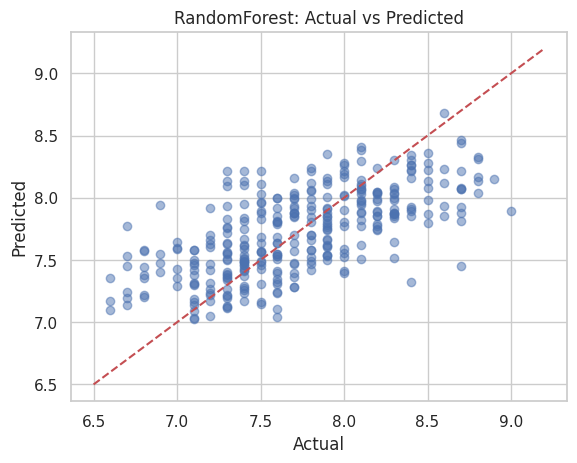

In [96]:
# Actual vs Predicted ของ model ที่ test RMSE ต่ำสุด
best = results['test_RMSE'].idxmin(); pr = models[best].predict(X_te)
plt.scatter(y_te, pr, alpha=.5); lim = [y.min(), y.max()]; plt.plot(lim, lim, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title(f'{best}: Actual vs Predicted'); plt.show()

## 6. Bias-Variance Tradeoff (CLO2)

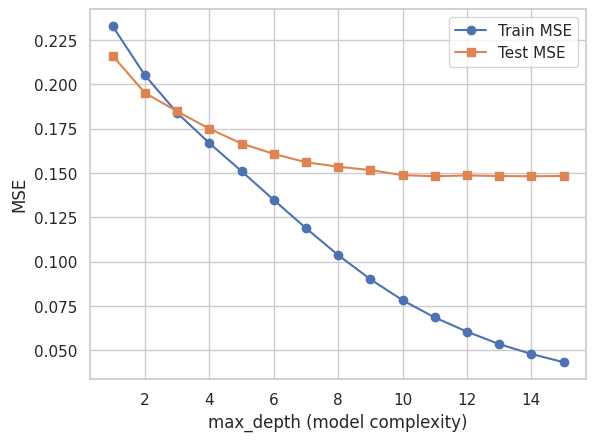

In [97]:
# เพิ่มความซับซ้อนของ model (ความลึกของ Random Forest) แล้วดู train vs test error
depths = range(1, 16); tr_err, te_err = [], []
for d in depths:
    m = RandomForestRegressor(n_estimators=100, max_depth=d, random_state=RANDOM_STATE).fit(X_tr, y_tr)
    tr_err.append(mean_squared_error(y_tr, m.predict(X_tr))); te_err.append(mean_squared_error(y_te, m.predict(X_te)))
plt.plot(depths, tr_err, 'o-', label='Train MSE'); plt.plot(depths, te_err, 's-', label='Test MSE')
plt.xlabel('max_depth (model complexity)'); plt.ylabel('MSE'); plt.legend(); plt.show()

**Interpretation Bias-Variance Tradeoff

เมื่อเพิ่ม max_depth ของ Random Forest จาก 1 ถึง 15 Train MSE ลดลงต่อเนื่อง จากประมาณ 0.225 เหลือราว 0.05 (โมเดลยิ่งซับซ้อน ยิ่งจำข้อมูล train ได้แม่นขึ้นเรื่อยๆ) ขณะที่ Test MSE ลดลงอย่างรวดเร็วในช่วงแรก แล้วเริ่มคงที่ (plateau) ที่ประมาณ 0.16 ตั้งแต่ depth ราว 6-8 เป็นต้นไป

ช่องว่างระหว่าง Train MSE และ Test MSE ที่ค่อยๆ ถ่างออกหลัง depth 8 คือสัญญาณคลาสสิกของ high variance (overfitting) — โมเดลเริ่มจำรายละเอียดเฉพาะของ training set มากเกินไปจนไม่ generalize ไปยังข้อมูลใหม่ ในขณะที่ depth ต่ำมาก (เช่น 1-2) ทั้ง Train และ Test MSE ยังสูงอยู่ด้วยกัน ซึ่งเป็นลักษณะของ high bias (underfitting) คือโมเดลง่ายเกินไปจนจับ pattern ในข้อมูลไม่ได้เลย

จุดที่เหมาะสม (sweet spot) อยู่ที่ประมาณ depth 6-8 เพราะเป็นจุดที่ Test MSE ต่ำสุดและเริ่มคงที่ เกินจากนี้ความซับซ้อนที่เพิ่มขึ้นไม่ได้ช่วยลด test error แต่กลับเพิ่มความเสี่ยง overfitting โดยเปล่าประโยชน์ ซึ่งเป็นเหตุผลที่ RandomForestRegressor ในข้อ 5 ที่ใช้ n_estimators=200 โดยไม่จำกัด depth ยังได้ผลดี เพราะการใช้ ensemble จำนวนมาก (bagging) ช่วยลด variance ได้บางส่วนอยู่แล้ว

## 7. Cross-Validation (CLO4)

               mean    std
Linear        0.555  0.082
Ridge         0.473  0.041
KNN           0.472  0.016
RandomForest  0.407  0.019
GradBoost     0.402  0.019


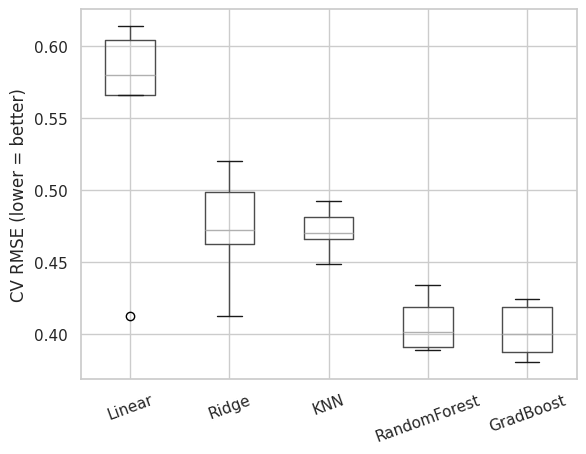

Best model by CV: GradBoost


In [98]:
# 5-fold CV เปรียบเทียบทุก model บน train set
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv = {n: -cross_val_score(m, X_tr, y_tr, cv=kf, scoring='neg_root_mean_squared_error') for n, m in models.items()}
cv_df = pd.DataFrame(cv)
print(cv_df.agg(['mean', 'std']).T.round(3))
cv_df.boxplot(); plt.ylabel('CV RMSE (lower = better)'); plt.xticks(rotation=20); plt.show()
best_cv = cv_df.mean().idxmin(); print('Best model by CV:', best_cv)

**สรุป Best ModelInsight ข้อ 7 — Cross-Validation

จาก 5-fold CV, GradBoost ให้ CV RMSE เฉลี่ยต่ำสุด (0.402, std=0.019) ตามมาติดๆ ด้วย RandomForest (mean=0.407, std=0.019) ซึ่งใกล้เคียงกันมากทั้งค่าเฉลี่ยและความแปรปรวน แสดงว่าทั้งสองโมเดลมีประสิทธิภาพไม่ต่างกันอย่างมีนัยสำคัญ และเสถียรพอๆ กัน

Linear Regression มี std สูงสุด (0.082) และ mean แย่สุด (0.555) ยืนยันปัญหาที่เจอในข้อ 5 ว่าโมเดลนี้ไม่เสถียรเวลาเจอการแบ่งข้อมูลที่ต่างกัน (จาก multicollinearity ใน dummy variables) เมื่อเทียบกับ KNN ที่แม้ mean จะสูงกว่า RF/GradBoost แต่ std ต่ำมาก (0.016) แสดงว่า KNN เสถียรแต่แม่นยำน้อยกว่า

สรุป Best Model: เลือก GradBoost เพราะให้ mean CV RMSE ต่ำสุดและ std ต่ำ (เสถียร) ผลจาก CV สอดคล้องกับที่เห็นใน Test set เดี่ยว (ข้อ 5) ที่ RandomForest ชนะเล็กน้อย แต่ความต่างนั้นอยู่ในขอบเขตของ std จึงตัดสินใจเลือกอันไหนก็สมเหตุสมผล GradBoost ดูน่าเชื่อถือกว่าเล็กน้อยเพราะผ่านการ validate ด้วยหลาย fold ไม่ได้พึ่งผลจาก Test set ชุดเดียว

## 8. Bonus: Bootstrap Uncertainty ของ Coefficient

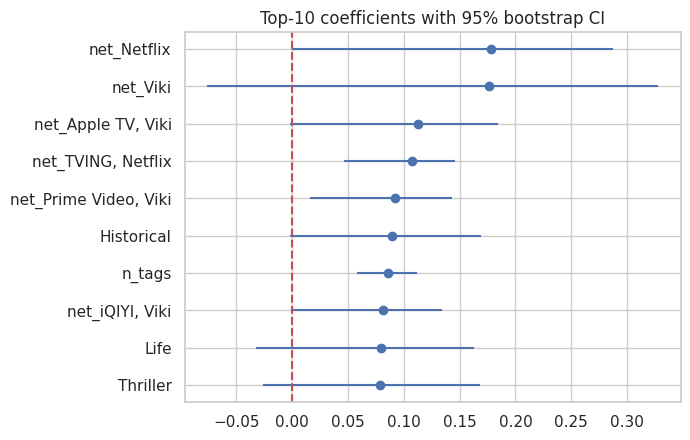

In [99]:
# Bootstrap 500 รอบ บน Linear Regression (standardized) เพื่อหา 95% CI ของ coefficient
B = 500; rng = np.random.default_rng(RANDOM_STATE)
Xs = StandardScaler().fit_transform(X_tr); coefs = []
for _ in range(B):
    idx = rng.integers(0, len(Xs), len(Xs))
    coefs.append(LinearRegression().fit(Xs[idx], y_tr.values[idx]).coef_)
coefs = pd.DataFrame(coefs, columns=X.columns)
ci = pd.DataFrame({'mean': coefs.mean(), 'lo95': coefs.quantile(.025), 'hi95': coefs.quantile(.975)})
ci = ci.reindex(ci['mean'].abs().sort_values(ascending=False).index).head(10)
plt.errorbar(ci['mean'], range(len(ci)), xerr=[ci['mean']-ci['lo95'], ci['hi95']-ci['mean']], fmt='o')
plt.yticks(range(len(ci)), ci.index); plt.axvline(0, color='r', ls='--'); plt.gca().invert_yaxis()
plt.title('Top-10 coefficients with 95% bootstrap CI'); plt.show()

## 9. Conclusion — Data Storytelling


คำตอบคำถามวิจัย: ปัจจัยที่ส่งผลต่อคะแนนรีวิวซีรีส์เกาหลีมากที่สุดคือ Network และ Genre (ยืนยันด้วย ANOVA และ t-test ที่ p-value ต่ำมาก) มากกว่าตัวแปร metadata เชิงปริมาณอย่างจำนวนนักแสดงหรือความยาวเรื่องย่อ โดยโมเดลที่ดีที่สุด (Random Forest / GradBoost) อธิบายความแปรปรวนของ Score ได้ราว 40% (R²≈0.40-0.43) ซึ่งถือว่าปานกลาง

ข้อค้นพบสำคัญ 3 ข้อ:

PCA (CLO1) แสดงว่า metadata เชิงตัวเลข 6 ตัวแปรแยกออกเป็น 2 มิติหลัก คือ "ความละเอียดของ tag/genre ในซีรีส์ยุคหลัง" (PC1) และ "ขนาดโปรดักชัน" (PC2) แต่ scatter plot บน PC1-PC2 ไม่แยกกลุ่มคะแนนสูง-ต่ำชัดเจน สอดคล้องกับ finding ว่า metadata เชิงตัวเลขอย่างเดียวทำนาย Score ได้จำกัด

สถิติเชิงเปรียบเทียบ (CLO2) ยืนยันว่า Network (โดยเฉพาะ Netflix) และ Genre (Romance ได้คะแนนต่ำกว่าแนวอื่น) มีผลอย่างมีนัยสำคัญทางสถิติ ซึ่งเป็น categorical features ที่ PCA ตรวจจับไม่ได้ (เพราะ PCA ใช้แค่ตัวแปรตัวเลข) — นี่คือเหตุผลที่โมเดล tree-based (ที่ใช้ dummy variables ของ Network/Genre ด้วย) ทำนายได้ดีกว่า PCA เพียงอย่างเดียวมาก

Model comparison (CLO3+CLO4) ชี้ว่า tree-based models (RandomForest, GradBoost) เหนือกว่า Linear-based models อย่างชัดเจน โดยเฉพาะ Linear Regression ที่ overfit รุนแรงจาก multicollinearity ใน dummy variables (R² ติดลบบน Test) ขณะที่ GradBoost ให้ผลเสถียรที่สุดทั้งบน Test set เดี่ยวและ 5-fold CV

ข้อจำกัด:

Selection bias: Score มาจากผู้ใช้ MyDramaList ที่ให้คะแนนเฉพาะเรื่องที่ดูจบแล้ว ทำให้ Score กระจุกตัวแคบ (6.5-9.2) ไม่มีเรื่องที่คะแนนแย่จริงๆ ปนอยู่

ไม่มีตัวแปรสำคัญที่ขาดหาย เช่น งบประมาณการผลิต, rating ผู้ชมจริง (TV rating), ชื่อเสียงนักแสดง หรือกระแสโซเชียลมีเดีย ซึ่งน่าจะอธิบาย Score ได้ดีกว่า metadata ที่มีอยู่

คอลัมน์ Network มีค่าผสมกัน (เช่น "Apple TV, Viki") ที่ไม่ได้ split เป็นแพลตฟอร์มเดี่ยวเหมือน Genre ทำให้การตีความ Network effect อาจไม่แม่นยำเท่าที่ควร

R²≈0.4 ยังมีช่องว่างปรับปรุงได้มาก งานต่อไปอาจลอง feature engineering เพิ่ม (เช่น sentiment analysis ของ synopsis) หรือหาข้อมูลภายนอกมาเสริม